# Machine Learning for Temperature Prediction
This notebook builds and compares three machine learning models to predict temperature based on weather data.

## 1. Import Libraries
Importing the necessary libraries for data analysis, modeling, and visualization.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load and Prepare Data
Loading the dataset and preparing it for the machine learning models. This includes selecting features and the target variable, and splitting the data.

In [6]:
# Load the dataset
df = pd.read_csv('nepal_weather_data.csv')
df.head()

,city,date,temp_max_c,temp_min_c,temperature,precipitation_mm,wind_speed_max,condition,source
0,Baglung,2026-03-12,NaN,NaN,22.2,NaN,NaN,Thunderstorm,BeautifulSoup
1,Banepa,2026-03-12,NaN,NaN,19.4,NaN,NaN,Thunderstorm,BeautifulSoup
2,Bhadrapur,2026-03-12,NaN,NaN,30.3,NaN,NaN,Thunderstorm,BeautifulSoup
3,Bhaktapur,2026-03-12,NaN,NaN,19.9,NaN,NaN,Light rain,BeautifulSoup
4,Bharatpur,2025-09-01,34.2,23.9,28.6,0.0,8.3,Overcast,Open-Meteo_API


In [7]:
# Display the column names to identify the correct ones
print(df.columns)

Index(['city', 'date', 'temp_max_c', 'temp_min_c', 'temperature',
       'precipitation_mm', 'wind_speed_max', 'condition', 'source'],
      dtype='object')


In [8]:
# Data Preparation
features = ['temp_max_c', 'precipitation_mm', 'wind_speed_max']
target = 'temperature'

# Drop rows with missing values in features or target
df.dropna(subset=features + [target], inplace=True)

# Select features and target
X = df[features]
y = df[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Build and Compare Models
Building and evaluating three different regression models.

In [9]:
# Model 1: Linear Regression (Baseline)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Evaluate Linear Regression
print("Linear Regression Performance:")
print(f"MAE: {mean_absolute_error(y_test, lr_preds)}")
print(f"MSE: {mean_squared_error(y_test, lr_preds)}")
print(f"R-squared: {r2_score(y_test, lr_preds)}")

Linear Regression Performance:
MAE: 1.1577883495746872
MSE: 2.1648890466919313
R-squared: 0.9274637698021476


In [10]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluate Random Forest Regressor
print("\nRandom Forest Regressor Performance:")
print(f"MAE: {mean_absolute_error(y_test, rf_preds)}")
print(f"MSE: {mean_squared_error(y_test, rf_preds)}")
print(f"R-squared: {r2_score(y_test, rf_preds)}")


Random Forest Regressor Performance:
MAE: 0.8679698836392209
MSE: 1.2549156893750228
R-squared: 0.957953109207838


In [11]:
# Model 3: Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

# Evaluate Gradient Boosting Regressor
print("\nGradient Boosting Regressor Performance:")
print(f"MAE: {mean_absolute_error(y_test, gb_preds)}")
print(f"MSE: {mean_squared_error(y_test, gb_preds)}")
print(f"R-squared: {r2_score(y_test, gb_preds)}")


Gradient Boosting Regressor Performance:
MAE: 0.86091271718726
MSE: 1.2389384582963998
R-squared: 0.9584884383108302


## 4. Visualize Predictions
Visualizing the performance of each model by plotting actual vs. predicted values.

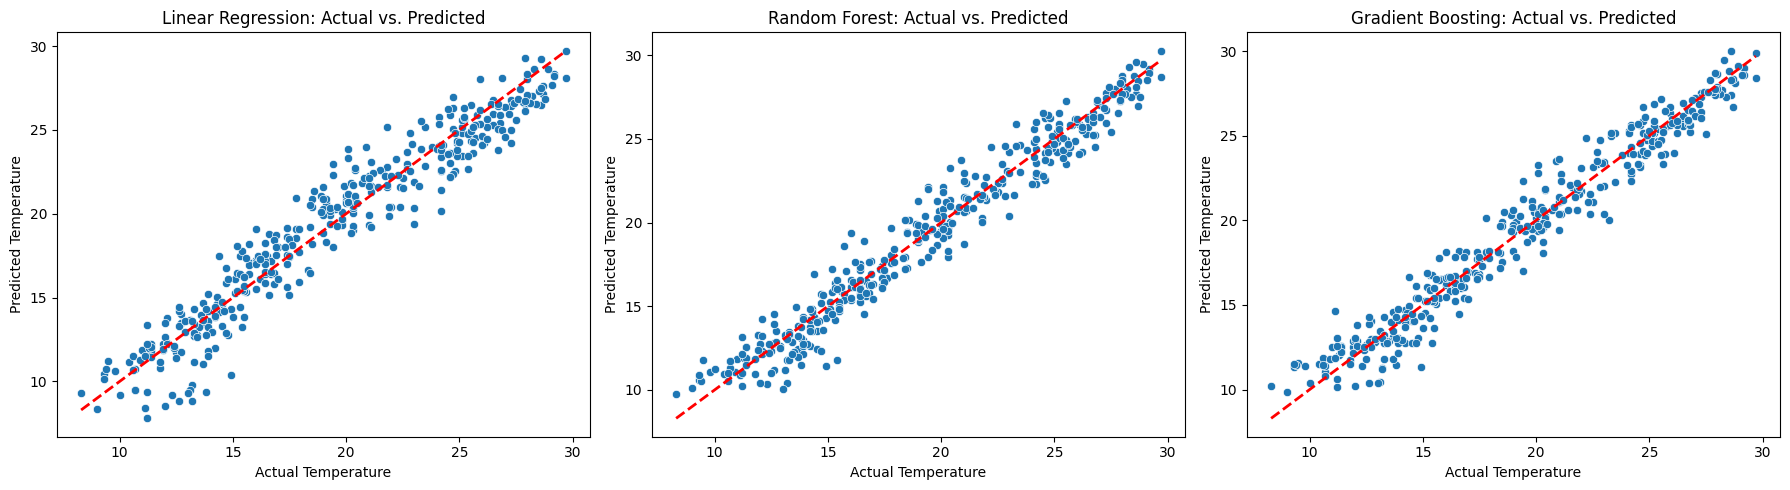

In [12]:
# Visualization of Predictions
plt.figure(figsize=(18, 5))

# Linear Regression Plot
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_test, y=lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')

# Random Forest Regressor Plot
plt.subplot(1, 3, 2)
sns.scatterplot(x=y_test, y=rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest: Actual vs. Predicted')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')

# Gradient Boosting Regressor Plot
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=gb_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Gradient Boosting: Actual vs. Predicted')
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')

plt.tight_layout()
plt.show()